In [1]:
from typing import TypedDict 
from langgraph.graph import StateGraph 

In [3]:
class AgentState(TypedDict):
    name : str 
    age : str 
    final : str 

In [13]:
def first_node(state : AgentState) -> AgentState:
    """This is the first node of the sequence"""
    print("First node")
    state["final"] = f'Hi {state["name"]}'
    return state 

def second_node(state : AgentState) -> AgentState:
    """This is the second node of the sequence"""
    print("Second node")
    state["final"] = state['final'] + f' You are {state["age"]} years old'
    return state 


In [14]:
graph = StateGraph(AgentState)
graph.add_node("first" , first_node)
graph.add_node("second" , second_node)

graph.add_edge("first" , "second") #adding an edge , to define flow of the graph

graph.set_entry_point("first")
graph.set_finish_point("second")

app = graph.compile()



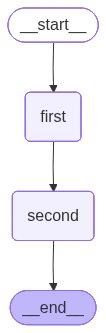

In [15]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [16]:
app.invoke({"name" : "Zaid" , "age" : "21"})

First node
Second node


{'name': 'Zaid', 'age': '21', 'final': 'Hi Zaid You are 21 years old'}